Final Weights: [0.08413244 0.90020792]
RMSE: 4.79446863756915


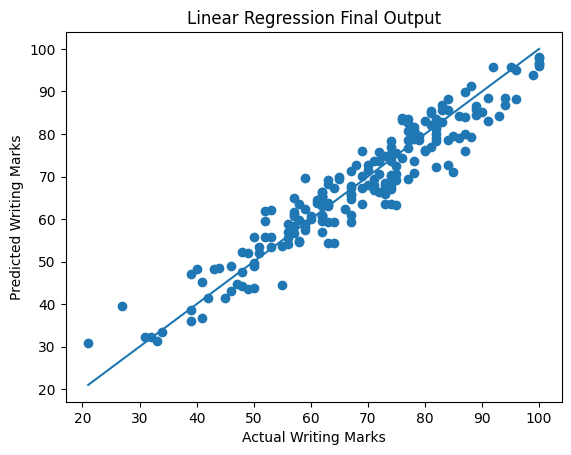

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('student.csv')

X = df[['Math', 'Reading']].values
y = df['Writing'].values

def training_testing_data(X, y, test_size=0.3, random_seed=42):
    np.random.seed(random_seed)
    n = X.shape[0]
    indices = np.random.permutation(n)
    test_count = int(test_size * n)
    test_idx = indices[:test_count]
    train_idx = indices[test_count:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def cost_function(X, y, W):
    n = len(y)
    return (1 / n) * np.sum((X @ W - y) ** 2)

def gradient_descent(X, y, W, learning_rate=0.0001, epochs=1000):
    n = len(y)
    cost_history = []
    for _ in range(epochs):
        gradient = (2 / n) * (X.T @ (X @ W - y))
        W = W - learning_rate * gradient
        cost_history.append(cost_function(X, y, W))
    return W, cost_history

def rmse(Y, Y_pred):
    return np.sqrt(np.mean((Y_pred - Y) ** 2))

def main():
    data = pd.read_csv('student.csv')
    X = data[['Math', 'Reading']].values
    Y = data['Writing'].values

    X_train, X_test, Y_train, Y_test = training_testing_data(X, Y, test_size=0.2)

    W = np.zeros(X_train.shape[1])
    W_optimal, cost_history = gradient_descent(X_train, Y_train, W)

    Y_pred = X_test @ W_optimal
    print("Final Weights:", W_optimal)
    print("RMSE:", rmse(Y_test, Y_pred))

    plt.figure()
    plt.scatter(Y_test, Y_pred)
    min_val = min(Y_test.min(), Y_pred.min())
    max_val = max(Y_test.max(), Y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val])
    plt.xlabel("Actual Writing Marks")
    plt.ylabel("Predicted Writing Marks")
    plt.title("Linear Regression Final Output")
    plt.show()

main()
